>## Importing Packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

### Step1. Load and Inspect Data

In [2]:
# Load Dataset
df = pd.read_excel("hotel_reviews .xlsx")
df.head(5)

,Review,Rating,@
0,nice hotel expensive parking got good deal sta...,4,NaN
1,ok nothing special charge diamond member hilto...,2,NaN
2,nice rooms not 4* experience hotel monaco seat...,3,NaN
3,"unique, great stay, wonderful time hotel monac...",5,NaN
4,"great stay great stay, went seahawk game aweso...",5,NaN


1. **Review** **-Text feedback written by the customer about their hotel experience.**
2. **Rating** **– Numerical score (usually from 1 to 5 or 1 to 10) given by the customer based on their experience.**

In [3]:
# Drop unnecessary columns
df = df.drop(columns=["@"], errors='ignore')
df.sample(6)

,Review,Rating
9153,great location-friendly staff recently spent n...,3
6464,nice economical convenient great staff great f...,4
13334,make sure meet weekend night reception guy sta...,5
18818,second visit palma real prfect returned palma ...,5
8224,"quality stay, week trip barcelona stayed barce...",4
5468,"hotel brunelleschi not thanks, husband stayed ...",3


In [4]:
df.shape

(20491, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB


In [6]:
# Basic Statistics
print("Total Reviews:", len(df))
print("Missing Values:")
print(df.isnull().sum())


Total Reviews: 20491
Missing Values:
Review    0
Rating    0
dtype: int64


>##### There is no missing values in the dataframe 

In [7]:
df.dtypes

Review    object
Rating     int64
dtype: object

In [8]:
df.duplicated().sum()

np.int64(0)

>##### No Duplicate Value In The Dataset

In [9]:
df.value_counts("Rating")

Rating
5    9054
4    6039
3    2184
2    1793
1    1421
Name: count, dtype: int64

### Step2. Basic Text Statistics

In [10]:
# Calculate total number of words in a review.
df['word_count'] = df['Review'].apply(lambda x: len(str(x).split()))

# Calculate total number of characters in a review.
df['char_count'] = df['Review'].apply(lambda x: len(str(x)))

# Calculate number of unique words in a review.
df['unique_word_count'] = df['Review'].apply(lambda x: len(set(str(x).split())))

# Display the first few rows
df[['Review', 'word_count', 'char_count', 'unique_word_count']].sample(3)



,Review,word_count,char_count,unique_word_count
3347,"hated leave concur recent reviews, stay great,...",34,235,32
13427,experience visited red lion 5th avenue night s...,82,549,71
6676,good time july 11-15. weather great hot beach ...,170,1102,141


In [11]:
df.describe()

,Rating,word_count,char_count,unique_word_count
count,20491.000000,20491.000000,20491.000000,20491.000000
mean,3.952223,104.375726,725.245571,86.508272
std,1.233030,100.656154,689.933070,71.330010
min,1.000000,7.000000,44.000000,7.000000
25%,3.000000,48.000000,339.000000,44.000000
50%,4.000000,77.000000,537.000000,67.000000
75%,5.000000,124.000000,859.000000,105.000000
max,5.000000,1931.000000,13501.000000,1205.000000


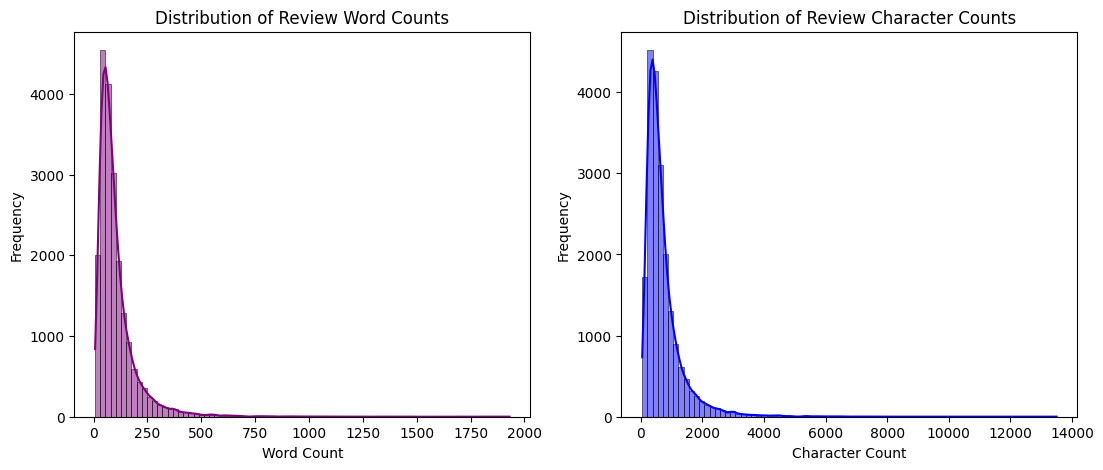

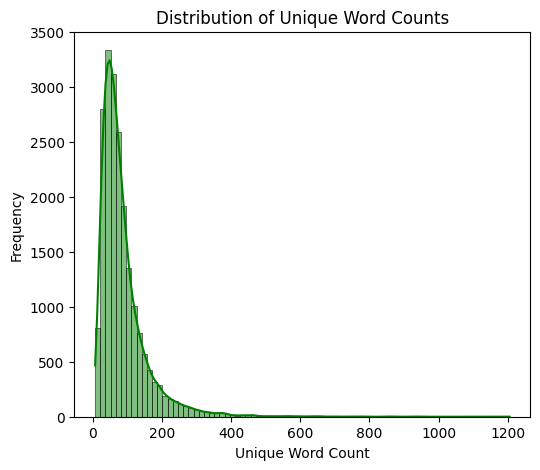

In [12]:
# Distribution of Review  Word Lengths
  
plt.figure(figsize=(20, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['word_count'], bins=80, kde=True, color='purple')
plt.title("Distribution of Review Word Counts")
plt.xlabel("Word Count")
plt.ylabel("Frequency")


# Distribution of Review Char Lengths

plt.subplot(1, 3, 2)
sns.histplot(df['char_count'], bins=80, kde=True, color='blue')
plt.title("Distribution of Review Character Counts")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.show()


# Distribution of Unique word Lengths
plt.figure(figsize=(20, 5))
plt.subplot(1, 3, 3)
sns.histplot(df['unique_word_count'], bins=80, kde=True, color='green')
plt.title("Distribution of Unique Word Counts")
plt.xlabel("Unique Word Count")
plt.ylabel("Frequency")
plt.show()



>##### These graphs help you understand your data.
            They show that most people:
          -->Write short reviews
          -->Use simple words
          -->Don’t write too much

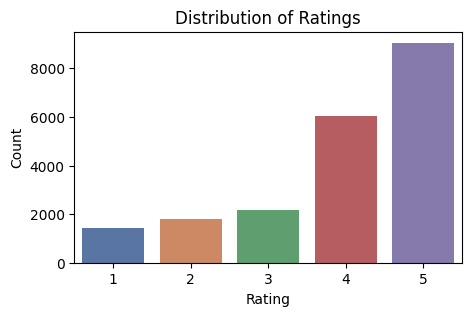

In [13]:
# Plot Rating Distribution

plt.figure(figsize=(5, 3))
sns.countplot(x='Rating', data=df,	palette="deep")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

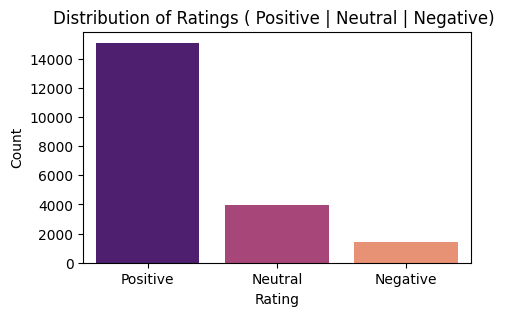

In [14]:
def Rating_label(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 2 or rating == 3 :
        return "Neutral"
    else:
        return "Negative"
df['Rating'] = df['Rating'].apply(Rating_label)


# Plotting the graph

plt.figure(figsize=(5, 3))
sns.countplot(x='Rating', data=df, palette="magma")
plt.title("Distribution of Ratings ( Positive | Neutral | Negative) ")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [15]:
df.value_counts("Rating")

Rating
Positive    15093
Neutral      3977
Negative     1421
Name: count, dtype: int64

>##### Encode ["Rating"] labels numerically (Negative=0, Neutral=1, Positive=2)

### Step3. Text Cleaning & Preprocessing

In [16]:
# Import the necessary libraries 
import re 
import string 
import nltk 
from nltk.corpus import stopwords 
from nltk.stem import WordNetLemmatizer , PorterStemmer 
from nltk.tokenize import word_tokenize 

In [17]:
# Downloads necessary NLP resources
nltk.download('punkt', quiet=True)      # Tokenizer (splits text into words/sentences)
nltk.download('stopwords', quiet=True)  # List of common stopwords (e.g., "the", "is", "in")
nltk.download('wordnet', quiet=True)     # WordNet dictionary for lemmatization (reducing words to base form)


True

In [18]:
# Load Stopwords and Lemmatizer
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# Function to clean text
def clean_text(text):
    text = text.lower()      # Convert to lowercase
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = re.sub(r'http\S+', '', text)  # Remove URLs  
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # Remove special characters
    text = text.translate(str.maketrans("", "", string.punctuation))  # Remove punctuation
    tokens = text.split()  # Tokenize
    # Remove Stopwords and Lemmatize  
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]  
    # Join back to a single string 
    cleaned_text = ' '.join(cleaned_tokens)
    # return function 
    return cleaned_text  

# Apply cleaning function
df["Cleaned_Review"] = df["Review"].apply(clean_text)
df.head(4)


,Review,Rating,word_count,char_count,unique_word_count,Cleaned_Review
0,nice hotel expensive parking got good deal sta...,Positive,87,593,77,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,Neutral,250,1689,188,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,Neutral,217,1427,161,nice room experience hotel monaco seattle good...
3,"unique, great stay, wonderful time hotel monac...",Positive,89,600,75,unique great stay wonderful time hotel monaco ...


In [19]:
print(df["Rating"].unique())  # Check unique values in the Rating column


['Positive' 'Neutral' 'Negative']


In [20]:
# Generate Text for Each Sentiment Category
positive_text = " ".join(df[df['Rating'] == "Positive"]['Cleaned_Review'])
neutral_text = " ".join(df[df['Rating'] == "Neutral"]['Cleaned_Review'])
negative_text = " ".join(df[df['Rating'] == "Negative"]['Cleaned_Review'])

# Print Sample Text from Each Category
print("\033[1m Positive Text Sample:\033[0m", positive_text[:500])  # First 500 characters of positive reviews
print("*" * 150)
print("\033[1m Neutral Text Sample:\033[0m", neutral_text[:500])  # First 500 characters of neutral reviews
print("*" * 150)
print("\033[1m Negative Text Sample:\033[0m", negative_text[:500])  # First 500 characters of negative reviews


 Positive Text Sample: nice hotel expensive parking got good deal stay hotel anniversary arrived late evening took advice previous review valet parking check quick easy little disappointed non existent view room room clean nice size bed comfortable woke stiff neck high pillow soundproof like heard music room night morning loud bang door opening closing hear people talking hallway maybe noisy neighbor aveda bath product nice goldfish stay nice touch taken advantage staying longer location great walking distance shoppin
******************************************************************************************************************************************************
 Neutral Text Sample: ok nothing special charge diamond member hilton decided chain shot th anniversary seattle start booked suite paid extra website description suite bedroom bathroom standard hotel room took printed reservation desk showed said thing like tv couch ect desk clerk told oh mixed suite description kimpton web

### Step4. Word Frequency Analysis

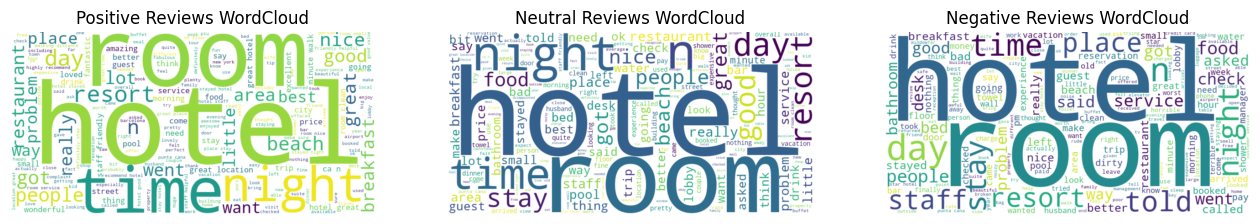

In [21]:
# Import necessary libraries
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Set figure size
plt.figure(figsize=(16, 10))  # (w*h)

# Create Word Cloud for Positive Reviews
plt.subplot(1, 3, 1)
wordcloud_pos = WordCloud(background_color='white', width=800, height=400).generate(positive_text)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.title("Positive Reviews WordCloud")
plt.axis("off")

# Create Word Cloud for Neutral Reviews
plt.subplot(1, 3, 2)
wordcloud_neu = WordCloud(background_color='white', width=800, height=400).generate(neutral_text)
plt.imshow(wordcloud_neu, interpolation='bilinear')
plt.title("Neutral Reviews WordCloud")
plt.axis("off")

# Create Word Cloud for Negative Reviews
plt.subplot(1, 3, 3)
wordcloud_neg = WordCloud(background_color='white', width=800, height=400).generate(negative_text)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.title("Negative Reviews WordCloud")
plt.axis("off")

# Show both Word Clouds
plt.show()

### Encode binary variables into label encoder(e.g 0/1 columns)

In [22]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()   # to convert categorical variable to numerical

# Encode ["Rating_Encoded"] labels numerically (Negative=0, Neutral=1, Positive=2)
df["Rating"] = label_encoder.fit_transform(df["Rating"]) 
df.sample(4)


,Review,Rating,word_count,char_count,unique_word_count,Cleaned_Review
16199,not worth money hotel coveniently located oppo...,1,145,1017,127,worth money hotel coveniently located opposite...
2997,"good holiday husband princess march break, vip...",2,123,834,102,good holiday husband princess march break vip ...
7987,"inn opera great inn opera wonderful hotel, sma...",2,44,331,41,inn opera great inn opera wonderful hotel smal...
12378,"small rooms incredibly small, room small suitc...",1,57,399,48,small room incredibly small room small suitcas...


### Step5.  Word Embeddings Convert text to numerical vectors

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)  # Convert text to numerical vectors

# Transform the cleaned text column
X = tfidf.fit_transform(df["Cleaned_Review"])
y = df["Rating"]
#print(X)
#print(y)
print("*"*50)

# Show shape of vectorized data
print(f"TF-IDF Matrix Shape: {X.shape}")


**************************************************
TF-IDF Matrix Shape: (20491, 5000)


### Data Balancing 

In [24]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state =42)
X_balanced , y_balanced = ros.fit_resample(X,y)

balanced_df = pd.DataFrame({'Rating': y_balanced})
balanced_df.value_counts("Rating")

Rating
0    15093
1    15093
2    15093
Name: count, dtype: int64

In [25]:
y_balanced .value_counts("Rating")

Rating
2    0.333333
1    0.333333
0    0.333333
Name: proportion, dtype: float64

### Split the dataset into training and testing sets 

In [26]:
from sklearn.model_selection import train_test_split

# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

# Show data sizes
print(f"Training data: {X_train.shape}, Testing data: {X_test.shape}")


Training data: (36223, 5000), Testing data: (9056, 5000)


### Step6. Model Development 

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report , confusion_matrix

# Train Logistic Regression Model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Predictions
y_pred_lr = log_reg.predict(X_test)

# Evaluate Performance
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.909452296819788
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.96      2986
           1       0.87      0.86      0.87      3007
           2       0.92      0.88      0.90      3063

    accuracy                           0.91      9056
   macro avg       0.91      0.91      0.91      9056
weighted avg       0.91      0.91      0.91      9056

Confusion Matrix:
 [[2946   40    0]
 [ 181 2598  228]
 [  18  353 2692]]


## Predicitive System For Checking How The Model Is Working 

In [28]:
# Prediction function to predict sentiment of a given text
def predict_sentiment(Text):
    cleaned = clean_text(Text)  # Clean the user input (remove unwanted symbols, lowercase, etc.)
    
    transformed_Text = tfidf.transform([cleaned])  # Convert the cleaned text into a numeric format using TF-IDF
    
    prediction = log_reg.predict(transformed_Text)[0]  # Predict sentiment using the model and get the result (0, 1, or 2)

    label_map = {0: "Negative Review", 1: "Neutral Review", 2: "Positive Review"}  # Mapping numbers to readable labels
    
    return label_map[prediction]  # Return the final label like "Positive Review"


In [34]:
df.sample(4)

,Review,Rating,word_count,char_count,unique_word_count,Cleaned_Review
3373,disappointed searching inexpensive honeymoon j...,1,106,760,91,disappointed searching inexpensive honeymoon j...
7600,"ikea, love renaissance parc55 san francisco an...",0,83,551,78,ikea love renaissance parc san francisco anxio...
15618,great breakfasts deal difficult membership pro...,2,42,353,33,great breakfast deal difficult membership prog...
13162,nice room expensive evrything went vacation an...,1,29,206,24,nice room expensive evrything went vacation an...


#### Text Input For The Model

In [39]:
# 0 output --> Negative 
# 1 output --> Neutral 
# 2 output --> Positive

Text = input("\033[1m Enter a hotel review:\033[0m")
print(predict_sentiment(Text))

 Enter a hotel review: great breakfasts deal difficult membership pro...	


Positive Review


### Uing Pickle Library To Save This Model And Files

In [31]:
import joblib

# Save label encoder
joblib.dump(label_encoder, "label_encoder.pkl")

# Save trained logistic regression model
joblib.dump(log_reg, "logistic_model.pkl")

# Save tfidf vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl");

### Model Completion Succesfully

 Model has been trained and saved successfully.

---> The dataset has been cleaned and preprocessed.

---> The dataset has been split into training and testing sets with a test size of 20%.

---> Logistic Regression model with the highest accuracy score is approximately **90% ~ 91%**

---> The model has been saved to a Joblib file named "logistic_model.pkl" . 

--->This file can be used to load the trained model and make predictions on new data.